##  Phase 1 – Problem Understanding & Dataset Analysis

### Industrial Context
Steel plates manufactured by Tata Steel undergo continuous rolling and cooling processes
that introduce **micro-level surface cracks** — hairline fractures typically 0.1–2mm wide
and invisible to the naked eye at production speed. If undetected before shipment, these
cracks cause catastrophic failures in end-use applications (automotive frames, bridges,
pressure vessels).

**Why manual inspection fails:**
- Lines run at 10–20 m/s; a human cannot scan 1600px-wide images in real time
- Cracks have low contrast against mill-scale surface noise (similar textures)
- Class imbalance: ~70% of plates have no defect → humans develop confirmation bias

**Our solution:** A two-stage deep learning pipeline —
- **Stage 1 (ResNet):** patch-wise crack/no-crack classifier → plate-level heatmap
- **Stage 2 (U-Net):** pixel-level segmentation for precise crack boundary localization
- **XAI (Grad-CAM):** explainability layer for production engineer trust

### Dataset: Severstal Steel Defect Detection (Kaggle)
- ~12,600 training images, resolution 256×1600px (grayscale converted to 3-ch)
- 4 defect classes encoded as RLE masks; Class 1 = surface cracks (our focus)
- ~6% of pixels are defective; severe class imbalance at patch level

### Evaluation Metrics
| Task | Metric | Justification |
|------|--------|---------------|
| Patch classification | **F1 / Precision / Recall** | Imbalanced classes; raw accuracy misleads |
| Plate-level decision | **ROC-AUC** | Threshold-independent; suits QC go/no-go |
| Segmentation | **Dice coefficient, IoU** | Overlap-based; standard for medical/industrial seg |
| Segmentation | **Pixel-wise F1** | Handles severe foreground sparsity |

In [1]:
# ── Cell 1: Setup (Local) ──────────────────────────────────────────────────────
!pip install -q albumentations

import os, glob
print("Setup done.")

Setup done.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Cell 2: Config + Plate-level train/val/test split ─────────────────────────
import pandas as pd, numpy as np, json, glob
from sklearn.model_selection import train_test_split

# Paths relative to your project folder (where the notebook lives)
IMAGE_DIR = "train_images"
TRAIN_CSV = "train.csv"

cfg = {
    "image_dir": IMAGE_DIR,
    "train_csv": TRAIN_CSV,
    "img_h": 256, "img_w": 1600,
    "patch_size": 256, "patch_stride": 128,
    "crack_class_id": 1,
    "val_frac": 0.15, "test_frac": 0.10, "seed": 42,
}

# Read CSV — Severstal has headers: ImageId, ClassId, EncodedPixels
df = pd.read_csv(cfg["train_csv"])
print("Columns found:", df.columns.tolist())
print("Sample rows:\n", df.head(3))

# Rename columns robustly regardless of capitalisation
df.columns = [c.strip() for c in df.columns]
col_map = {}
for c in df.columns:
    cl = c.lower()
    if "image" in cl:   col_map[c] = "ImageId"
    elif "class" in cl: col_map[c] = "ClassId"
    elif "encoded" in cl or "pixel" in cl: col_map[c] = "EncodedPixels"
df.rename(columns=col_map, inplace=True)

# Convert ClassId to int safely
df["ClassId"] = pd.to_numeric(df["ClassId"], errors="coerce")
df = df.dropna(subset=["ClassId"])
df["ClassId"] = df["ClassId"].astype(int)

# All unique plate IDs (from image filenames in the folder)
import os
all_ids   = sorted(os.listdir(IMAGE_DIR))
has_crack = set(
    df[(df["ClassId"] == cfg["crack_class_id"]) & (df["EncodedPixels"].notna())]["ImageId"]
)

# Split by plate ID
train_ids, temp    = train_test_split(all_ids, test_size=cfg["val_frac"]+cfg["test_frac"],
                                      random_state=cfg["seed"])
val_ids,  test_ids = train_test_split(temp,
                                      test_size=cfg["test_frac"]/(cfg["val_frac"]+cfg["test_frac"]),
                                      random_state=cfg["seed"])

json.dump({"train": train_ids, "val": val_ids, "test": test_ids},
          open("split_indices.json", "w"))

print(f"\nTotal plates  : {len(all_ids)}")
print(f"  Train : {len(train_ids)}  |  Val : {len(val_ids)}  |  Test : {len(test_ids)}")
print(f"  Cracked plates : {len(has_crack)} / {len(all_ids)}")
print(f"\nColumns after fix: {df.columns.tolist()}")

Columns found: ['ImageId', 'ClassId', 'EncodedPixels']
Sample rows:
          ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...

Total plates  : 12568
  Train : 9426  |  Val : 1885  |  Test : 1257
  Cracked plates : 897 / 12568

Columns after fix: ['ImageId', 'ClassId', 'EncodedPixels']


In [3]:
# ── Cell 3: Dataset classes + DataLoader factory ───────────────────────────────
import cv2, torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def decode_rle(rle, h=256, w=1600):
    mask = np.zeros(h * w, dtype=np.uint8)
    if pd.isna(rle): return mask.reshape(h, w, order="F")
    s = list(map(int, str(rle).split()))
    for start, length in zip(s[0::2], s[1::2]):
        mask[start-1 : start-1+length] = 1
    return mask.reshape(h, w, order="F")

def get_transforms(split):
    base = [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()]
    if split != "train": return A.Compose(base)
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5),
        *base
    ])

# Separate seg transforms — NO ToTensorV2, we handle it manually
def get_seg_transforms(split):
    base = [A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))]
    if split != "train": return A.Compose(base)
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5),
        *base
    ])

class SteelPatchDataset(Dataset):
    """Stage 1: overlapping patches → crack / clean labels."""
    def __init__(self, image_ids, df, cfg, split="train"):
        self.df, self.cfg, self.transform = df, cfg, get_transforms(split)
        ps, st = cfg["patch_size"], cfg["patch_stride"]
        H, W   = cfg["img_h"], cfg["img_w"]
        self.patches = [(i, r, c) for i in image_ids
                        for r in range(0, H-ps+1, st)
                        for c in range(0, W-ps+1, st)]

    def __len__(self): return len(self.patches)

    def __getitem__(self, idx):
        img_id, r, c = self.patches[idx]
        ps = self.cfg["patch_size"]
        img = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
        crack_row = self.df[(self.df["ImageId"]==img_id) & (self.df["ClassId"]==1)]
        rle  = crack_row.iloc[0]["EncodedPixels"] if not crack_row.empty else np.nan
        mask = decode_rle(rle)
        patch_img, patch_mask = img[r:r+ps, c:c+ps], mask[r:r+ps, c:c+ps]
        label = 1 if patch_mask.sum() > 0 else 0
        out = self.transform(image=patch_img, mask=patch_mask)
        return out["image"], torch.tensor(label, dtype=torch.long)

class SteelSegDataset(Dataset):
    """Stage 2: full-plate tiles → image + binary crack mask pairs."""
    def __init__(self, image_ids, df, cfg, split="train", tile_w=512):
        self.df, self.cfg, self.tile_w = df, cfg, tile_w
        self.aug = get_seg_transforms(split)   # no ToTensorV2 here
        self.tiles = [(i, c) for i in image_ids
                      for c in range(0, cfg["img_w"]-tile_w+1, tile_w)]

    def __len__(self): return len(self.tiles)

    def __getitem__(self, idx):
        img_id, c = self.tiles[idx]
        img  = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
        row  = self.df[(self.df["ImageId"]==img_id) & (self.df["ClassId"]==1)]
        rle  = row.iloc[0]["EncodedPixels"] if not row.empty else np.nan
        mask = decode_rle(rle)
        img_tile  = img[:,  c:c+self.tile_w]
        mask_tile = mask[:, c:c+self.tile_w]
        out = self.aug(image=img_tile, mask=mask_tile)
        # out["image"] is np.ndarray here (no ToTensorV2), so from_numpy is safe
        img_out  = torch.from_numpy(out["image"]).permute(2, 0, 1).float()
        mask_out = torch.from_numpy(out["mask"]).unsqueeze(0).float()
        return img_out, mask_out

def build_loaders(split, dataset_class, **kwargs):
    ids = json.load(open("split_indices.json"))[split]
    ds  = dataset_class(ids, df, cfg, split=split, **kwargs)
    # num_workers=0 for local VS Code (avoids Windows multiprocessing issues)
    return DataLoader(ds, batch_size=16, shuffle=(split=="train"), num_workers=0)

# Smoke test
patch_loader = build_loaders("train", SteelPatchDataset)
seg_loader   = build_loaders("train", SteelSegDataset, tile_w=512)
x, y = next(iter(patch_loader))
print(f"Stage 1 patch batch : {tuple(x.shape)}  labels {y.unique().tolist()}")
x, m = next(iter(seg_loader))
print(f"Stage 2 seg batch   : {tuple(x.shape)}  mask {tuple(m.shape)}")

Stage 1 patch batch : (16, 3, 256, 256)  labels [0, 1]
Stage 2 seg batch   : (16, 3, 256, 512)  mask (16, 1, 256, 512)


FFT: 40 cracked, 40 clean plates processed.


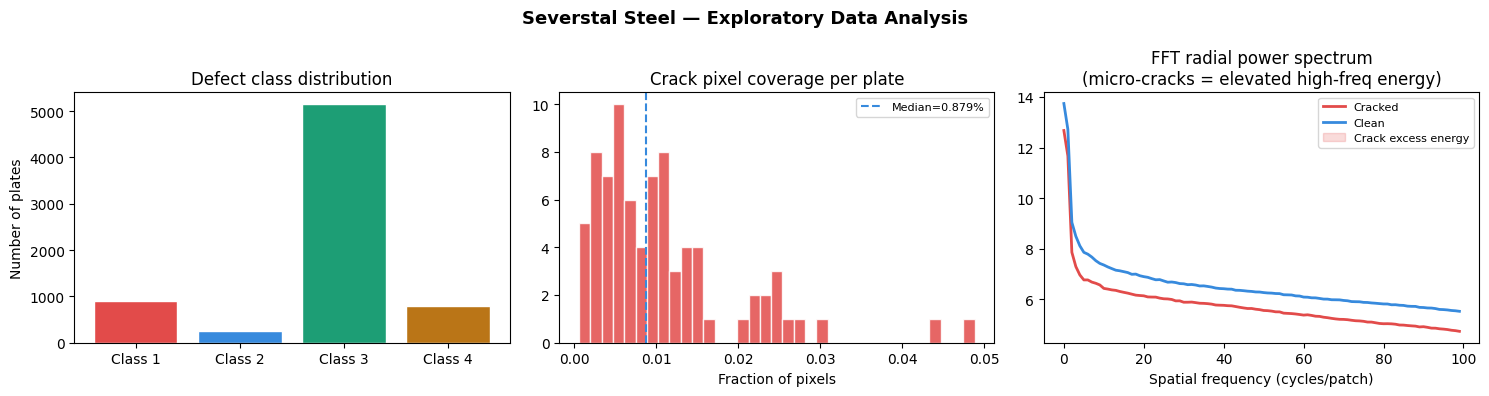

In [4]:
# ── Cell 4: EDA ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import cv2, numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Severstal Steel — Exploratory Data Analysis", fontsize=13, fontweight="bold")

# ── Plot 1: class distribution ─────────────────────────────────────────────────
class_counts = [df[df["ClassId"]==c]["ImageId"].nunique() for c in [1,2,3,4]]
axes[0].bar([f"Class {i+1}" for i in range(4)], class_counts,
            color=["#E24B4A","#378ADD","#1D9E75","#BA7517"], edgecolor="white")
axes[0].set_title("Defect class distribution")
axes[0].set_ylabel("Number of plates")

# ── Plot 2: crack pixel coverage ───────────────────────────────────────────────
coverages = []
for img_id in list(has_crack)[:80]:
    row = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    if not row.empty and not pd.isna(row.iloc[0]["EncodedPixels"]):
        coverages.append(decode_rle(row.iloc[0]["EncodedPixels"]).mean())

axes[1].hist(coverages, bins=35, color="#E24B4A", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(coverages), color="#378ADD", lw=1.5, linestyle="--",
                label=f"Median={np.median(coverages)*100:.3f}%")
axes[1].set_title("Crack pixel coverage per plate")
axes[1].set_xlabel("Fraction of pixels")
axes[1].legend(fontsize=8)

# ── Plot 3: FFT radial power spectrum ──────────────────────────────────────────
def fft_spectrum(img_gray):
    patch = img_gray[:256, :256].astype(np.float32)
    window = np.outer(np.hanning(256), np.hanning(256))
    f = np.fft.fftshift(np.fft.fft2(patch * window))
    return np.log1p(np.abs(f))

def radial_profile(spec):
    cy, cx = 128, 128
    y, x = np.indices(spec.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tally  = np.bincount(r.ravel(), weights=spec.ravel())
    counts = np.bincount(r.ravel())
    with np.errstate(invalid="ignore"):
        result = np.where(counts > 0, tally / counts, 0.0)
    return result

crack_set = set(has_crack)
crack_rp, clean_rp = [], []

sample_cracked = list(has_crack)[:40]
sample_clean   = [i for i in all_ids if i not in crack_set][:40]

for img_id in sample_cracked + sample_clean:
    img_path = f"{cfg['image_dir']}/{img_id}"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"  Warning: could not load {img_id}, skipping.")
        continue
    if img.shape[0] < 256 or img.shape[1] < 256:
        print(f"  Warning: {img_id} too small ({img.shape}), skipping.")
        continue
    rp = radial_profile(fft_spectrum(img))
    if img_id in crack_set:
        crack_rp.append(rp)
    else:
        clean_rp.append(rp)

print(f"FFT: {len(crack_rp)} cracked, {len(clean_rp)} clean plates processed.")

if len(crack_rp) > 0 and len(clean_rp) > 0:
    min_len = min(min(len(r) for r in crack_rp), min(len(r) for r in clean_rp))
    cr = np.mean([r[:min_len] for r in crack_rp], axis=0)[:100]
    cl = np.mean([r[:min_len] for r in clean_rp], axis=0)[:100]
    f  = np.arange(len(cr))

    axes[2].plot(f, cr, color="#E24B4A", lw=2, label="Cracked")
    axes[2].plot(f, cl, color="#378ADD", lw=2, label="Clean")
    axes[2].fill_between(f, cr, cl, where=(cr > cl),
                         alpha=0.2, color="#E24B4A", label="Crack excess energy")
    axes[2].set_title("FFT radial power spectrum\n(micro-cracks = elevated high-freq energy)")
    axes[2].set_xlabel("Spatial frequency (cycles/patch)")
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "Not enough images loaded\nfor FFT analysis",
                 ha="center", va="center", transform=axes[2].transAxes, color="gray")
    print("Could not compute FFT — check that cfg['image_dir'] is correct:",
          cfg["image_dir"])

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

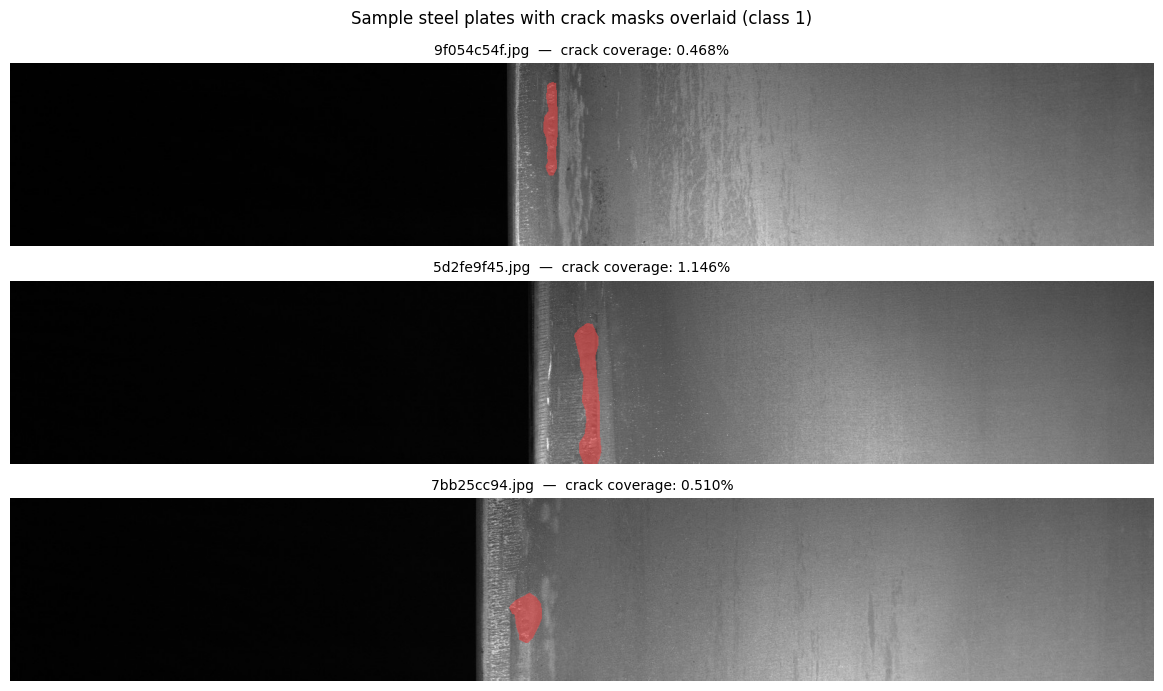

Saved: sample_plates.png


In [5]:
# ── Cell 5: Visual — sample cracked plates with mask overlay ──────────────────
import matplotlib.pyplot as plt

sample_ids = list(has_crack)[:3]

fig, axes  = plt.subplots(3, 1, figsize=(14, 7))
fig.suptitle("Sample steel plates with crack masks overlaid (class 1)", fontsize=12)

for ax, img_id in zip(axes, sample_ids):
    img  = cv2.cvtColor(cv2.imread(f"{cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
    row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    mask = decode_rle(row.iloc[0]["EncodedPixels"] if not row.empty else np.nan)
    overlay = img.astype(float)
    overlay[mask==1] = overlay[mask==1]*0.35 + np.array([226,75,74])*0.65
    ax.imshow(overlay.astype(np.uint8))
    crack_pct = mask.mean()*100
    ax.set_title(f"{img_id}  —  crack coverage: {crack_pct:.3f}%", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_plates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_plates.png")

In [6]:
# ── Cell 6: Stage 1 — ResNet patch classifier ────────────────────────────────
import torch, torch.nn as nn, numpy as np, json, time
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── Model ─────────────────────────────────────────────────────────────────────
def build_resnet(backbone="resnet18"):
    model = getattr(models, backbone)(weights="IMAGENET1K_V1")
    for p in model.parameters():
        p.requires_grad_(True)
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 2)
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model  = build_resnet("resnet18").to(device)

# ── Balanced sampler ──────────────────────────────────────────────────────────
print("Counting patch labels (takes ~2 min)...")
train_ids = json.load(open("split_indices.json"))["train"]
train_ds  = SteelPatchDataset(train_ids, df, cfg, split="train")

labels_list = [train_ds[i][1].item() for i in range(len(train_ds))]
n_crack = sum(labels_list)
n_clean = len(labels_list) - n_crack
print(f"Train patches — Crack: {n_crack} | Clean: {n_clean} | Ratio: {n_clean/max(n_crack,1):.1f}:1")

class_weights = [n_clean / max(n_crack, 1) if l == 1 else 1.0 for l in labels_list]
sampler = WeightedRandomSampler(class_weights, num_samples=len(class_weights), replacement=True)

# num_workers=0 for local VS Code
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = build_loaders("val", SteelPatchDataset)

# ── Loss + Optimizer ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0], device=device))

backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
head_params     = list(model.fc.parameters())

optimizer = AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params,     "lr": 5e-4},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Training loop ─────────────────────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n    = len(all_labels)
    f1   = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
    prec = precision_score(all_labels, all_preds, pos_label=1, zero_division=0)
    rec  = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    return total_loss/n, f1, prec, rec

history = {"train_loss":[], "val_loss":[], "val_f1":[]}
best_f1   = 0.0
best_ckpt = "best_resnet.pth"
NUM_EPOCHS = 20

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_f1, tr_p, tr_r = run_epoch(train_loader, train=True)
    va_loss, va_f1, va_p, va_r = run_epoch(val_loader,   train=False)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_f1"].append(va_f1)
    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "optimizer": optimizer.state_dict(), "best_val_f1": best_f1, "cfg": cfg,
        }, best_ckpt)
    print(f"Ep {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss {tr_loss:.4f} F1 {tr_f1:.3f} | "
          f"Val loss {va_loss:.4f} F1 {va_f1:.3f} P {va_p:.3f} R {va_r:.3f} | "
          f"{time.time()-t0:.0f}s")

json.dump(history, open("train_history.json", "w"))
print(f"\nBest val F1: {best_f1:.4f}  →  {best_ckpt}")

Using device: cuda
Counting patch labels (takes ~2 min)...
Train patches — Crack: 2246 | Clean: 101440 | Ratio: 45.2:1
Ep 01/20 | Train loss 0.1777 F1 0.902 | Val loss 0.1459 F1 0.521 P 0.365 R 0.910 | 832s
Ep 02/20 | Train loss 0.1099 F1 0.940 | Val loss 0.1081 F1 0.629 P 0.532 R 0.768 | 821s
Ep 03/20 | Train loss 0.0919 F1 0.948 | Val loss 0.1448 F1 0.573 P 0.431 R 0.852 | 816s
Ep 04/20 | Train loss 0.0835 F1 0.953 | Val loss 0.1163 F1 0.668 P 0.555 R 0.838 | 815s
Ep 05/20 | Train loss 0.0740 F1 0.957 | Val loss 0.1141 F1 0.688 P 0.613 R 0.784 | 813s
Ep 06/20 | Train loss 0.0676 F1 0.961 | Val loss 0.1178 F1 0.669 P 0.574 R 0.800 | 816s
Ep 07/20 | Train loss 0.0638 F1 0.963 | Val loss 0.1287 F1 0.699 P 0.687 R 0.712 | 813s
Ep 08/20 | Train loss 0.0599 F1 0.965 | Val loss 0.1222 F1 0.759 P 0.818 R 0.708 | 815s
Ep 09/20 | Train loss 0.0564 F1 0.966 | Val loss 0.1156 F1 0.756 P 0.780 R 0.733 | 816s
Ep 10/20 | Train loss 0.0520 F1 0.969 | Val loss 0.1497 F1 0.733 P 0.841 R 0.650 | 817s
E

In [7]:
# ── Cell 6b: Save & Load trained model (Local) ────────────────────────────────
import os, torch

SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = f"{SAVE_DIR}/resnet18_best.pth"
torch.save({
    "epoch":        NUM_EPOCHS,
    "model_state":  model.state_dict(),
    "optimizer":    optimizer.state_dict(),
    "scheduler":    scheduler.state_dict(),
    "best_val_f1":  best_f1,
    "cfg":          cfg,
}, save_path)
print(f"Checkpoint saved to: {save_path}")

# ── To load later ─────────────────────────────────────────────────────────────
# ckpt = torch.load("checkpoints/resnet18_best.pth", map_location=device)
# model = build_resnet("resnet18").to(device)
# model.load_state_dict(ckpt["model_state"])
# model.eval()
# print(f"Loaded | Best val F1: {ckpt['best_val_f1']:.4f}")

Checkpoint saved to: checkpoints/resnet18_best.pth


In [12]:
!pip install seaborn -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Dr. Payal\AppData\Local\Temp\ipykernel_14728\2739295943.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_location=device)


              precision    recall  f1-score   support

       Clean     0.9954    0.9973    0.9964     13555
       Crack     0.8531    0.7684    0.8085       272

    accuracy                         0.9928     13827
   macro avg     0.9242    0.8829    0.9024     13827
weighted avg     0.9926    0.9928    0.9927     13827

ROC-AUC: 0.9881


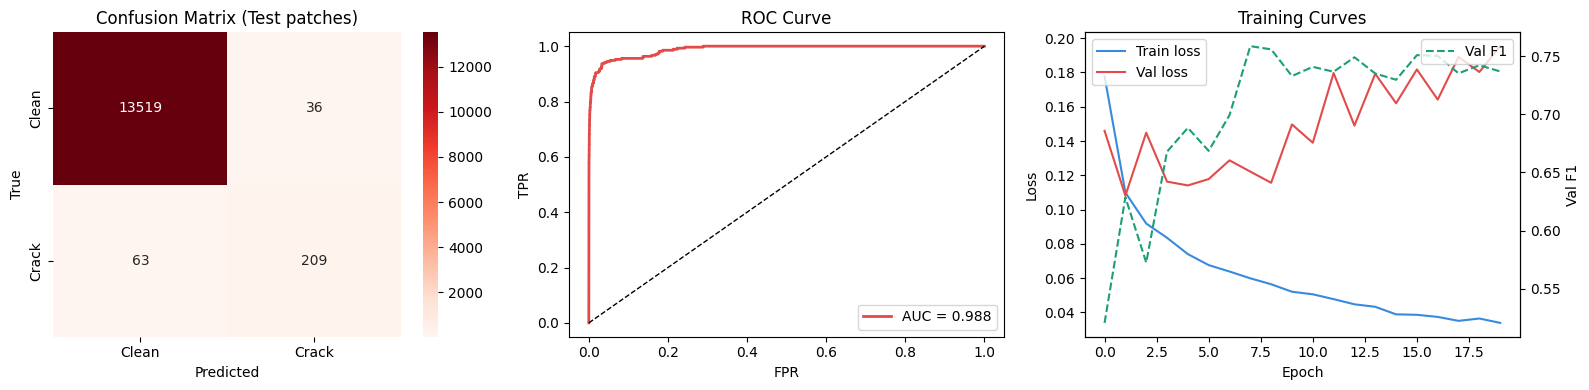

In [19]:
# ── Cell 7: Full evaluation on test set ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_loader = build_loaders("test", SteelPatchDataset)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
                             target_names=["Clean","Crack"], digits=4))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {auc:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Clean","Crack"], yticklabels=["Clean","Crack"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix (Test patches)")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, lw=2, color="#E24B4A", label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend()

# Training curves
axes[2].plot(history["train_loss"], label="Train loss", color="#378ADD")
axes[2].plot(history["val_loss"],   label="Val loss",   color="#E24B4A")
ax2 = axes[2].twinx()
ax2.plot(history["val_f1"], label="Val F1", color="#1D9E75", linestyle="--")
axes[2].set_title("Training Curves")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss"); ax2.set_ylabel("Val F1")
axes[2].legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ── Cell 8b: Plots saved locally ──────────────────────────────────────────────
# All plots (eda_plots.png, sample_plates.png, evaluation_plots.png, heatmaps.png)
# are saved directly in your project folder.
print("All plots saved in the project folder.")

All plots saved in the project folder.


C:\Users\Dr. Payal\AppData\Local\Temp\ipykernel_14728\532870612.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_location=device)


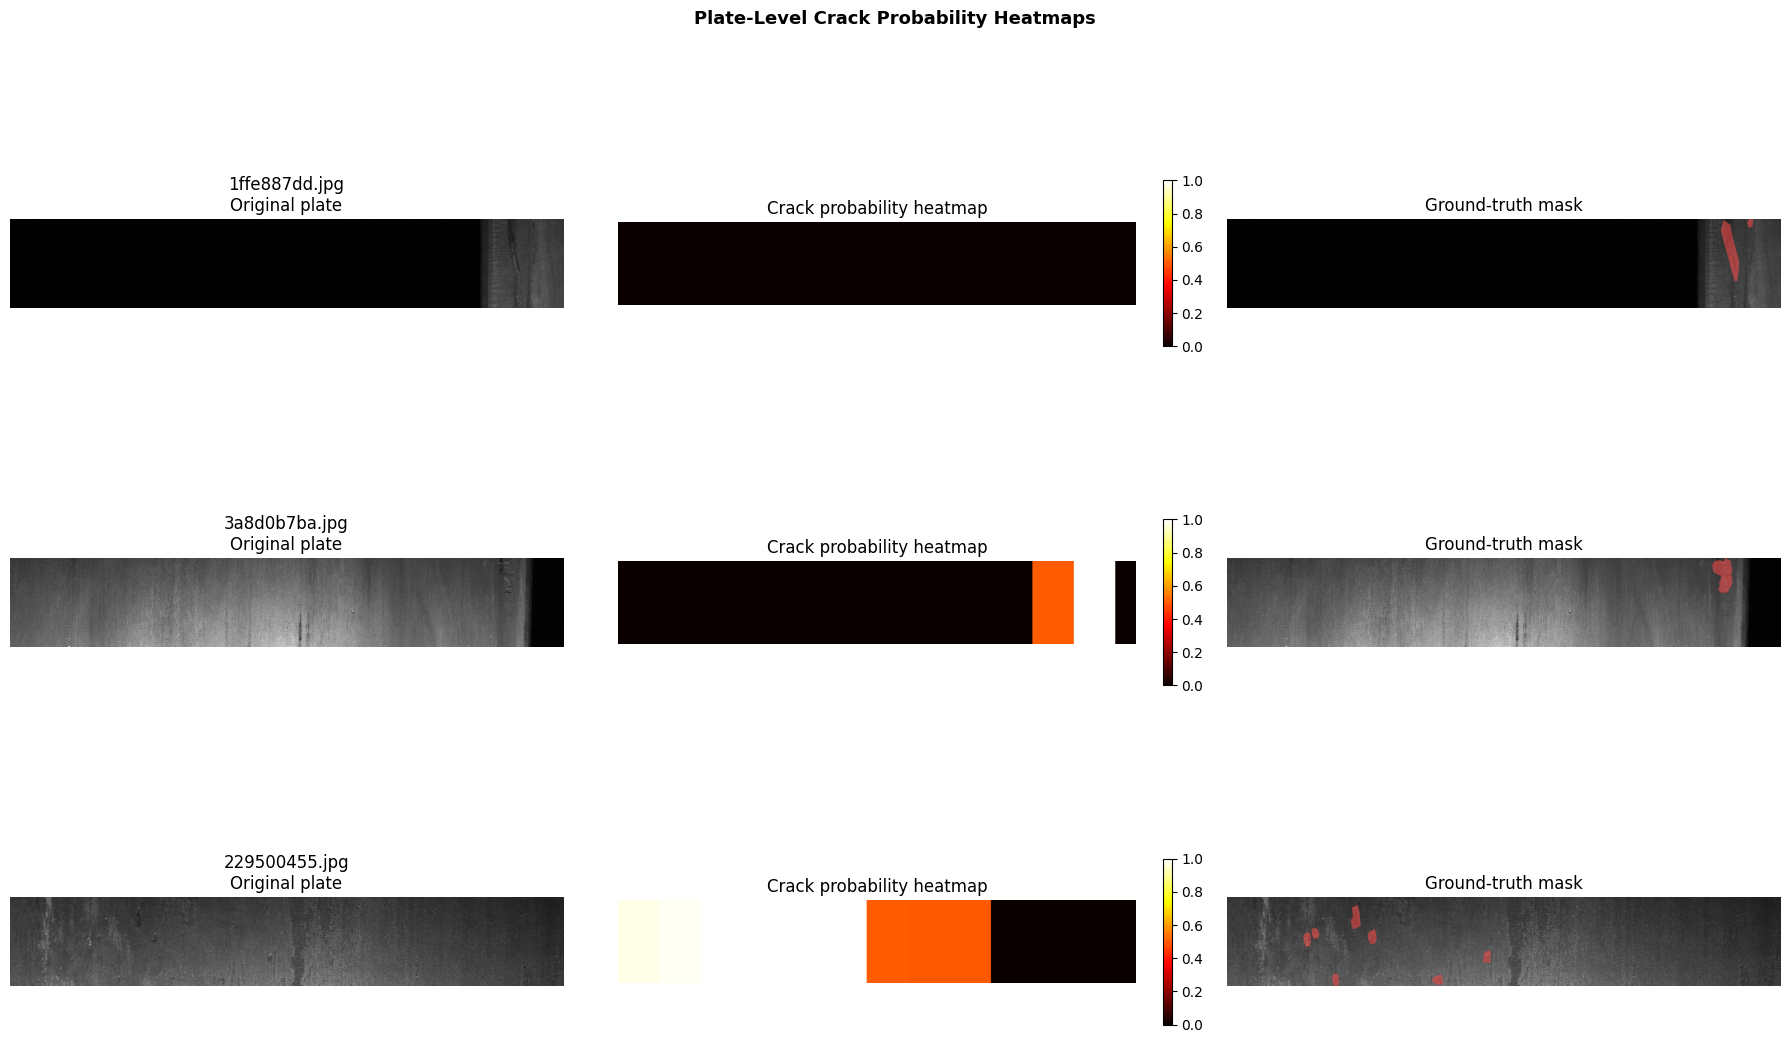

Saved: heatmaps.png


In [22]:
# ── Cell 8: Plate-level heatmaps from patch predictions ───────────────────────
import torch, numpy as np, cv2, matplotlib.pyplot as plt
from torch.utils.data import DataLoader

ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

def generate_heatmap(image_id, df, cfg, model, device):
    """
    Slide a 256×256 window across a plate with stride=128.
    Accumulate crack probability into a float accumulator, average overlapping regions.
    Returns: (original_image_rgb, heatmap_256x1600 float32)
    """
    ps, st = cfg["patch_size"], cfg["patch_stride"]
    H, W   = cfg["img_h"], cfg["img_w"]
    img    = cv2.cvtColor(cv2.imread(f"{cfg['image_dir']}/{image_id}"),
                          cv2.COLOR_BGR2RGB)
    accum  = np.zeros((H, W), dtype=np.float32)
    count  = np.zeros((H, W), dtype=np.float32)
    tfm    = get_transforms("val")

    patches, coords = [], []
    for r in range(0, H-ps+1, st):
        for c in range(0, W-ps+1, st):
            patch = img[r:r+ps, c:c+ps]
            t     = tfm(image=patch)["image"]
            patches.append(t)
            coords.append((r, c))

    batch_size = 64
    for i in range(0, len(patches), batch_size):
        batch = torch.stack(patches[i:i+batch_size]).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(batch), dim=1)[:,1].cpu().numpy()
        for j, (r, c) in enumerate(coords[i:i+batch_size]):
            accum[r:r+ps, c:c+ps] += probs[j]
            count[r:r+ps, c:c+ps] += 1

    with np.errstate(invalid="ignore"):
        heatmap = np.where(count > 0, accum / count, 0)
    return img, heatmap


# ── Visualise 3 test plates ────────────────────────────────────────────────────
test_ids     = json.load(open("split_indices.json"))["test"]
cracked_test = [i for i in test_ids if i in has_crack][:3]
sample_ids   = cracked_test if cracked_test else test_ids[:3]

fig, axes = plt.subplots(len(sample_ids), 3,
                          figsize=(18, 4*len(sample_ids)))
fig.suptitle("Plate-Level Crack Probability Heatmaps", fontsize=13, fontweight="bold")

for row_i, img_id in enumerate(sample_ids):
    img, heatmap = generate_heatmap(img_id, df, cfg, model, device)

    gt_row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    gt_mask = decode_rle(gt_row.iloc[0]["EncodedPixels"]
                         if not gt_row.empty else np.nan)

    axes[row_i, 0].imshow(img)
    axes[row_i, 0].set_title(f"{img_id}\nOriginal plate")
    axes[row_i, 0].axis("off")

    im = axes[row_i, 1].imshow(heatmap, cmap="hot", vmin=0, vmax=1)
    axes[row_i, 1].set_title("Crack probability heatmap")
    axes[row_i, 1].axis("off")
    plt.colorbar(im, ax=axes[row_i, 1], fraction=0.015)

    overlay = img.astype(float).copy()
    overlay[gt_mask==1] = overlay[gt_mask==1]*0.35 + np.array([226,75,74])*0.65
    axes[row_i, 2].imshow(overlay.astype(np.uint8))
    axes[row_i, 2].set_title("Ground-truth mask")
    axes[row_i, 2].axis("off")

plt.tight_layout()
plt.savefig("heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmaps.png")

In [15]:
# ── Cell 9: Install segmentation models ───────────────────────────────────────
!pip install -q segmentation-models-pytorch

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt
import time



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# ── Cell 9.5: Stage-2 prerequisites (imports + base dataset) ─────────────────
!pip install -q segmentation-models-pytorch

import os, cv2, time, json, random
import numpy as np, pandas as pd, torch, torch.nn as nn
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Guarantee df, cfg, decode_rle, norm are live ----------------------------
try: df
except NameError:
    df = pd.read_csv("train.csv")
    df.columns = [c.strip() for c in df.columns]
    if "ImageId_ClassId" in df.columns:
        df[["ImageId","ClassId"]] = df["ImageId_ClassId"].str.split("_", expand=True)
        df["ClassId"] = df["ClassId"].astype(int)

try: cfg
except NameError:
    cfg = {"image_dir":"severstal-steel-defect-detection/train_images",
           "img_h":256, "img_w":1600, "patch_size":256, "patch_stride":128,
           "crack_class_id":1, "seed":42}

def decode_rle(rle, h=256, w=1600):
    mask = np.zeros(h*w, dtype=np.uint8)
    if pd.isna(rle): return mask.reshape(h, w, order="F")
    s = list(map(int, str(rle).split()))
    for start, length in zip(s[0::2], s[1::2]):
        mask[start-1:start-1+length] = 1
    return mask.reshape(h, w, order="F")

def seg_transforms(split):
    if split == "train":
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

# --- Base Stage-2 dataset: slides a 256×tile_w window across the plate -------
class SteelSegDataset(Dataset):
    """
    Emits (image_tensor, mask_tensor) tiles from Severstal plates.
    Height is always 256 (full plate height). Width = tile_w (default 512).
    Tiles are extracted at stride = tile_w//2 (50% overlap).
    Binary mask = class 1 only (crack).
    """
    def __init__(self, image_ids, df, cfg, split="train", tile_w=512):
        self.image_ids = list(image_ids)
        self.df, self.cfg, self.split, self.tile_w = df, cfg, split, tile_w
        self.tf  = seg_transforms(split)
        self.H, self.W = cfg["img_h"], cfg["img_w"]
        stride = tile_w // 2

        self.tiles = []     # list of (image_id, x_offset)
        for img_id in self.image_ids:
            for c in range(0, self.W - tile_w + 1, stride):
                self.tiles.append((img_id, c))

    def __len__(self): return len(self.tiles)

    def __getitem__(self, i):
        img_id, c = self.tiles[i]
        img = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"),
                           cv2.COLOR_BGR2RGB)
        row = self.df[(self.df["ImageId"]==img_id) & (self.df["ClassId"]==1)]
        rle = row.iloc[0]["EncodedPixels"] if not row.empty else np.nan
        mask = decode_rle(rle, self.H, self.W)

        img_tile  = img[:,  c:c+self.tile_w]
        mask_tile = mask[:, c:c+self.tile_w]

        out = self.tf(image=img_tile, mask=mask_tile)
        return out["image"], out["mask"].unsqueeze(0).float()   # (3,H,tile_w), (1,H,tile_w)

print("Stage-2 prerequisites ready.  smp:", smp.__version__)
print("SteelSegDataset + seg_transforms + decode_rle defined.")

Stage-2 prerequisites ready.  smp: 0.5.0
SteelSegDataset + seg_transforms + decode_rle defined.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# ── Cell 9.6: build_loaders factory (matches original Cell 3 interface) ──────
import json
from torch.utils.data import DataLoader

with open("split_indices.json") as f:
    SPLIT = json.load(f)              # {"train":[...], "val":[...], "test":[...]}

def build_loaders(split, dataset_cls, batch_size=None, shuffle=None, num_workers=0, **ds_kwargs):
    """
    split        : 'train' | 'val' | 'test'
    dataset_cls  : dataset class whose __init__ takes (image_ids, df, cfg, split, **ds_kwargs)
    ds_kwargs    : forwarded to the dataset (e.g. tile_w=512)
    """
    image_ids = SPLIT[split]

    # Try the richer signature first (SteelSegDataset / Balanced), fall back to patch signature
    try:
        ds = dataset_cls(image_ids, df, cfg, split=split, **ds_kwargs)
    except TypeError:
        ds = dataset_cls(image_ids, df, cfg, **ds_kwargs)     # SteelPatchDataset style

    if batch_size is None: batch_size = 8  if split=="train" else 16
    if shuffle    is None: shuffle    = (split == "train")

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=True)

print("build_loaders ready. splits:",
      {k: len(v) for k, v in SPLIT.items()})

build_loaders ready. splits: {'train': 9426, 'val': 1885, 'test': 1257}


In [17]:
# ── Cell 10: U-Net Model ──────────────────────────────────────────────────────
def build_unet(pretrained=True):
    encoder_weights = "imagenet" if pretrained else None
    
    model = smp.Unet(
        encoder_name="resnet34",   # balance between speed + accuracy
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=1,                 # binary mask
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pretrained = build_unet(pretrained=True).to(device)
model_random     = build_unet(pretrained=False).to(device)

print("Models ready")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Models ready


In [28]:
# cell 11: Focal Tversky Loss + Metrics for segmentation evaluation ─────────────────
bce = nn.BCEWithLogitsLoss()

def focal_tversky_loss(pred, target, alpha=0.7, beta=0.3, gamma=0.75):
    pred = torch.sigmoid(pred)

    TP = (pred * target).sum()
    FP = ((1 - target) * pred).sum()
    FN = (target * (1 - pred)).sum()

    tversky = (TP + 1e-6) / (TP + alpha*FP + beta*FN + 1e-6)
    return (1 - tversky) ** gamma


# NEW: Hybrid Loss
def hybrid_loss(pred, target):
    return focal_tversky_loss(pred, target) + 0.3 * bce(pred, target)


# Pixel-wise metrics (correct)
def compute_metrics_batch(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (
        pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + 1e-6
    )

    return iou.mean().item(), dice.mean().item()



In [30]:
# ── Cell 12a: Build Stage-2 loaders from split_indices.json ───────────────────
with open("split_indices.json") as f:
    split = json.load(f)

train_ds = SteelSegDataset(split["train"], df, cfg, split="train", tile_w=512)
val_ds   = SteelSegDataset(split["val"],   df, cfg, split="val",   tile_w=512)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)
print("train tiles:", len(train_ds), "| val tiles:", len(val_ds))

train tiles: 47130 | val tiles: 9425


In [31]:
# cell 12 training loop for segmentation model ─────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=25):

    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}

    for epoch in range(epochs):
        t0 = time.time()

        if epoch == 5:
            for p in model.encoder.parameters():
                p.requires_grad = True
            print("Encoder unfrozen")

        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            preds = model(imgs)

            # CHANGED
            loss = hybrid_loss(preds, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        scheduler.step()

        # Validation
        model.eval()
        val_loss, iou_total, dice_total = 0, 0, 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)

                # CHANGED
                loss = hybrid_loss(preds, masks)

                val_loss += loss.item()

                iou, dice = compute_metrics_batch(preds, masks)
                iou_total += iou
                dice_total += dice

        n = len(val_loader)

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / n)
        history["val_iou"].append(iou_total / n)
        history["val_dice"].append(dice_total / n)

        print(f"Epoch {epoch+1} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val IoU: {history['val_iou'][-1]:.4f} | "
              f"Val Dice: {history['val_dice'][-1]:.4f} | "
              f"{time.time()-t0:.0f}s")

    return history


In [32]:
# cell 13: Balanced dataset for segmentation — keep all positive tiles + sample negatives
import random

class SteelSegDatasetBalanced(SteelSegDataset):
    def __init__(self, image_ids, df, cfg, split="train", tile_w=512):
        super().__init__(image_ids, df, cfg, split, tile_w)

        pos_tiles = []
        neg_tiles = []

        for img_id, c in self.tiles:
            row = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
            rle = row.iloc[0]["EncodedPixels"] if not row.empty else np.nan
            mask = decode_rle(rle)

            tile_mask = mask[:, c:c+tile_w]

            if tile_mask.sum() > 0:
                pos_tiles.append((img_id, c))
            else:
                neg_tiles.append((img_id, c))

        # 🔥 Keep ALL positives + sample negatives
        neg_sample = random.sample(neg_tiles, min(len(neg_tiles), len(pos_tiles)//2))

        self.tiles = pos_tiles + neg_sample
        random.shuffle(self.tiles)

        print(f"{split} → Pos: {len(pos_tiles)}, Neg used: {len(neg_sample)}, Total: {len(self.tiles)}")


train_loader = build_loaders("train", SteelSegDatasetBalanced, tile_w=512)
val_loader   = build_loaders("val",   SteelSegDatasetBalanced, tile_w=512)

print("Training PRETRAINED model...")
hist_pre = train_model(model_pretrained, train_loader, val_loader, epochs=25)

print("\nTraining RANDOM model...")
hist_rand = train_model(model_random, train_loader, val_loader, epochs=25)



train → Pos: 1607, Neg used: 803, Total: 2410
val → Pos: 307, Neg used: 153, Total: 460
Training PRETRAINED model...
Epoch 1 | Train Loss: 1.0094 | Val IoU: 0.3269 | Val Dice: 0.4222 | 24s
Epoch 2 | Train Loss: 0.8173 | Val IoU: 0.4416 | Val Dice: 0.5268 | 23s
Epoch 3 | Train Loss: 0.6397 | Val IoU: 0.4492 | Val Dice: 0.5354 | 23s
Epoch 4 | Train Loss: 0.5813 | Val IoU: 0.4977 | Val Dice: 0.5827 | 23s
Epoch 5 | Train Loss: 0.5561 | Val IoU: 0.4758 | Val Dice: 0.5680 | 23s
Encoder unfrozen
Epoch 6 | Train Loss: 0.5532 | Val IoU: 0.5001 | Val Dice: 0.5909 | 29s
Epoch 7 | Train Loss: 0.5159 | Val IoU: 0.5657 | Val Dice: 0.6469 | 29s
Epoch 8 | Train Loss: 0.4851 | Val IoU: 0.4951 | Val Dice: 0.5888 | 29s
Epoch 9 | Train Loss: 0.4673 | Val IoU: 0.5542 | Val Dice: 0.6391 | 29s
Epoch 10 | Train Loss: 0.4592 | Val IoU: 0.5755 | Val Dice: 0.6617 | 29s
Epoch 11 | Train Loss: 0.4400 | Val IoU: 0.5678 | Val Dice: 0.6553 | 29s
Epoch 12 | Train Loss: 0.4166 | Val IoU: 0.5784 | Val Dice: 0.6638 | 29s

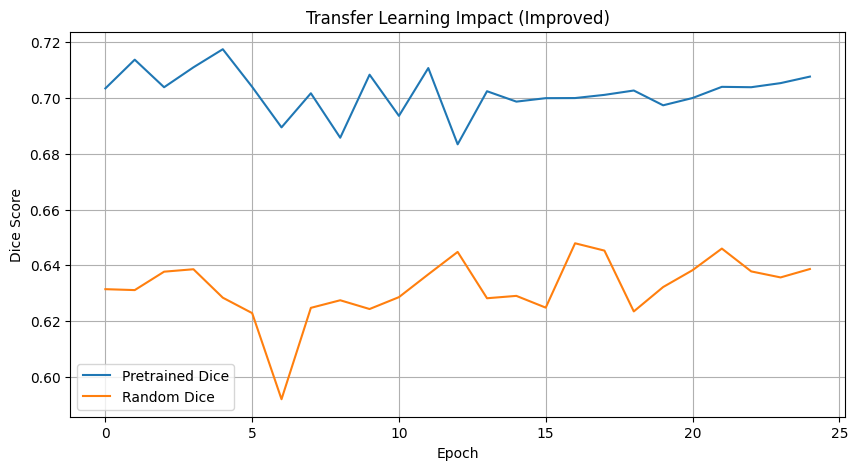

In [52]:
# ── Cell 14: Plot comparison ──────────────────────────────────────────────────
plt.figure(figsize=(10,5))

plt.plot(hist_pre["val_dice"], label="Pretrained Dice")
plt.plot(hist_rand["val_dice"], label="Random Dice")

plt.title("Transfer Learning Impact (Improved)")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid()
plt.show()



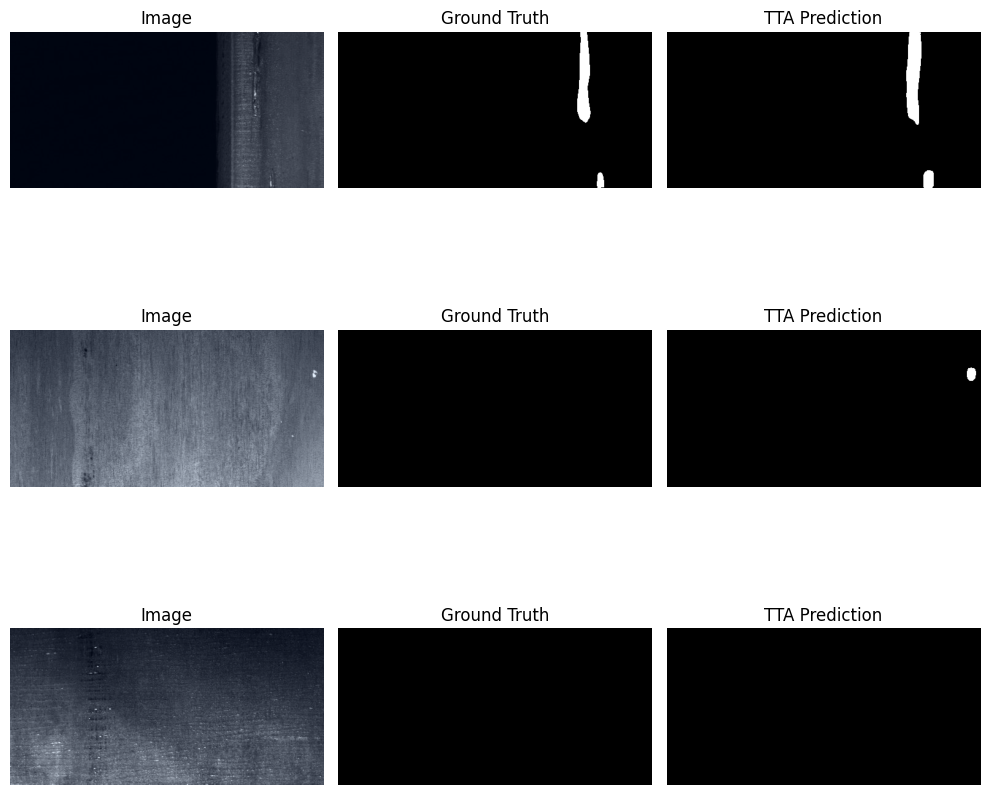

In [53]:
# ── Cell 15: Visual results ───────────────────────────────────────────────────
def tta_predict(model, imgs):
    preds = []

    # original
    preds.append(torch.sigmoid(model(imgs)))

    # horizontal flip
    imgs_flip = torch.flip(imgs, dims=[3])
    pred_flip = torch.sigmoid(model(imgs_flip))
    pred_flip = torch.flip(pred_flip, dims=[3])
    preds.append(pred_flip)

    return torch.mean(torch.stack(preds), dim=0)


model_pretrained.eval()

imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    preds = tta_predict(model_pretrained, imgs)

fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i in range(3):
    img = imgs[i].cpu().permute(1,2,0).numpy()
    
    # normalize for display
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    gt  = masks[i].cpu().squeeze().numpy()
    pr  = preds[i].cpu().squeeze().numpy()

    axes[i,0].imshow(img)
    axes[i,0].set_title("Image")

    axes[i,1].imshow(gt, cmap="gray")
    axes[i,1].set_title("Ground Truth")

    axes[i,2].imshow(pr > 0.5, cmap="gray")
    axes[i,2].set_title("TTA Prediction")

    for j in range(3):
        axes[i,j].axis("off")

plt.tight_layout()
plt.savefig("segmentation_results_improved.png")
plt.show()




In [54]:
# ── Cell 16: TorchScript export ───────────────────────────────────────────────
example = torch.randn(1, 3, 256, 256).to(device)

# TorchScript export
traced_model = torch.jit.trace(model_pretrained, example)
traced_model.save("unet_traced.pt")

print("TorchScript model saved!")

# Measure inference speed
model_pretrained.eval()
start = time.time()

with torch.no_grad():
    for _ in range(30):
        _ = model_pretrained(example)

end = time.time()

print("Avg inference time:", (end - start) / 30)


TorchScript model saved!
Avg inference time: 0.01443625291188558


In [1]:
!pip install -q segmentation-models-pytorch

import os
import json
import time
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
import segmentation_models_pytorch as smp


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# ── Cell 17: Phase-4 setup (loads everything from disk) ───────────────────────
import os, json, glob, time
import numpy as np, pandas as pd, cv2, torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --- Paths --------------------------------------------------------------------
ROOT        = os.getcwd()                                # PROJSTEEL/
CKPT_CLF    = "checkpoints/resnet18_best.pth"
CKPT_UNET   = "unet_traced.pt"
TRAIN_CSV   = "train.csv"
IMAGE_DIR   = "severstal-steel-defect-detection/train_images"
SPLIT_JSON  = "split_indices.json"
HIST_JSON   = "train_history.json"
for p in (CKPT_CLF, CKPT_UNET, TRAIN_CSV, IMAGE_DIR, SPLIT_JSON):
    assert os.path.exists(p), f"missing: {p}"

# --- Dataframe ----------------------------------------------------------------
df = pd.read_csv(TRAIN_CSV)
df.columns = [c.strip() for c in df.columns]
# Severstal sometimes has ImageId_ClassId combo — normalise
if "ImageId_ClassId" in df.columns:
    df[["ImageId","ClassId"]] = df["ImageId_ClassId"].str.split("_", expand=True)
    df["ClassId"] = df["ClassId"].astype(int)
has_crack = set(df[(df["ClassId"]==1) & df["EncodedPixels"].notna()]["ImageId"])
print(f"df: {len(df)} rows | plates with class-1 crack: {len(has_crack)}")

# --- Config -------------------------------------------------------------------
ckpt = torch.load(CKPT_CLF, map_location=device, weights_only=False)
cfg  = ckpt.get("cfg", {
    "image_dir": IMAGE_DIR, "train_csv": TRAIN_CSV,
    "img_h": 256, "img_w": 1600,
    "patch_size": 256, "patch_stride": 128,
    "crack_class_id": 1, "seed": 42,
})
cfg["image_dir"] = IMAGE_DIR      # override in case ckpt saved an old path
print("cfg:", cfg)

# --- Stage-1 classifier (weights from checkpoint) -----------------------------
def build_resnet(backbone="resnet18"):
    m = getattr(models, backbone)(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 2))
    return m

model = build_resnet("resnet18").to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Stage-1 ResNet18 loaded | best val F1: {ckpt.get('best_val_f1','?')}")

# --- Stage-2 U-Net (TorchScript) ---------------------------------------------
unet = torch.jit.load(CKPT_UNET, map_location=device).eval()
print("Stage-2 U-Net loaded (TorchScript).")

# --- Helpers -----------------------------------------------------------------
def decode_rle(rle, h=256, w=1600):
    mask = np.zeros(h*w, dtype=np.uint8)
    if pd.isna(rle): return mask.reshape(h, w, order="F")
    s = list(map(int, str(rle).split()))
    for start, length in zip(s[0::2], s[1::2]):
        mask[start-1:start-1+length] = 1
    return mask.reshape(h, w, order="F")

norm = A.Compose([A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                  ToTensorV2()])

# --- Grad-CAM ----------------------------------------------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.grads, self.acts = None, None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, _m, _i, out):  self.acts  = out.detach()
    def _bwd(self, _m, _gi, go):  self.grads = go[0].detach()
    def __call__(self, x, class_idx=1):
        logits = self.model(x)
        self.model.zero_grad()
        logits[:, class_idx].sum().backward()
        w = self.grads.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w * self.acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, torch.softmax(logits, 1)[0,1].item()

cam_obj = GradCAM(model, model.layer4[-1])

def overlay_cam(img_rgb, cam, alpha=0.45):
    heat = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (alpha*heat + (1-alpha)*img_rgb).astype(np.uint8)

print("Phase-4 setup complete. df, cfg, model, unet, cam_obj, decode_rle, norm are live.")

device: cuda
df: 7095 rows | plates with class-1 crack: 897
cfg: {'image_dir': 'severstal-steel-defect-detection/train_images', 'train_csv': 'train.csv', 'img_h': 256, 'img_w': 1600, 'patch_size': 256, 'patch_stride': 128, 'crack_class_id': 1, 'val_frac': 0.15, 'test_frac': 0.1, 'seed': 42}
Stage-1 ResNet18 loaded | best val F1: 0.7587064676616916
Stage-2 U-Net loaded (TorchScript).
Phase-4 setup complete. df, cfg, model, unet, cam_obj, decode_rle, norm are live.


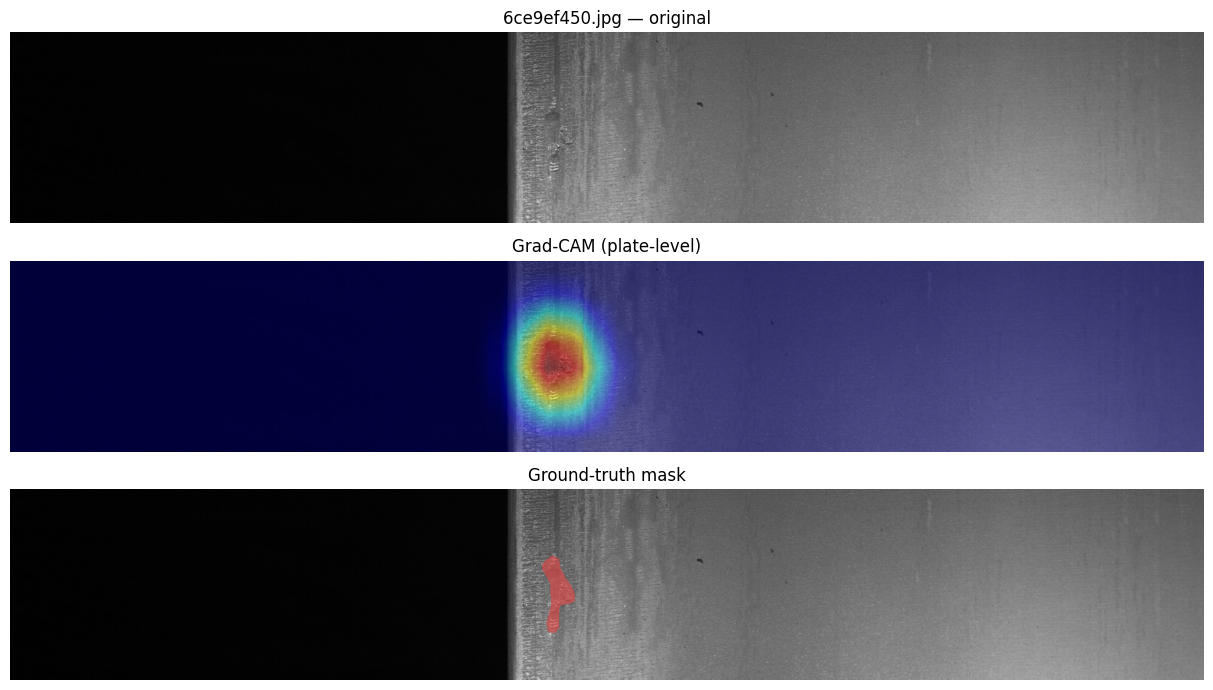

saved outputs/heatmaps/gradcam_6ce9ef450.png


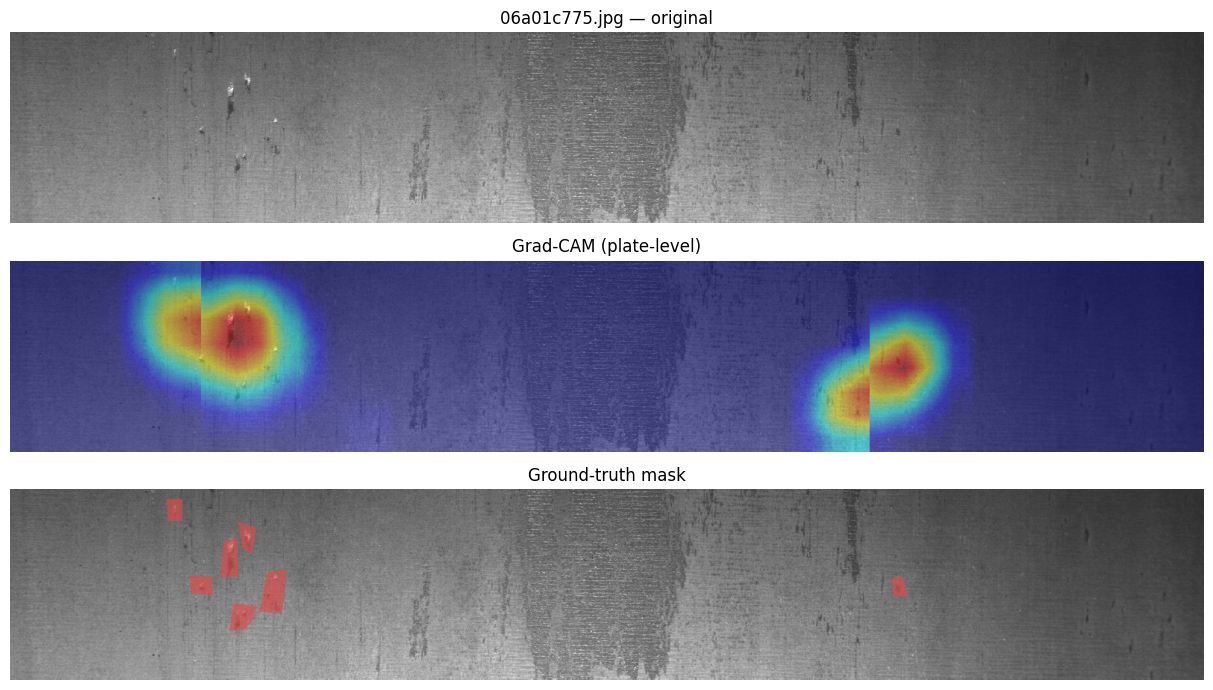

saved outputs/heatmaps/gradcam_06a01c775.png


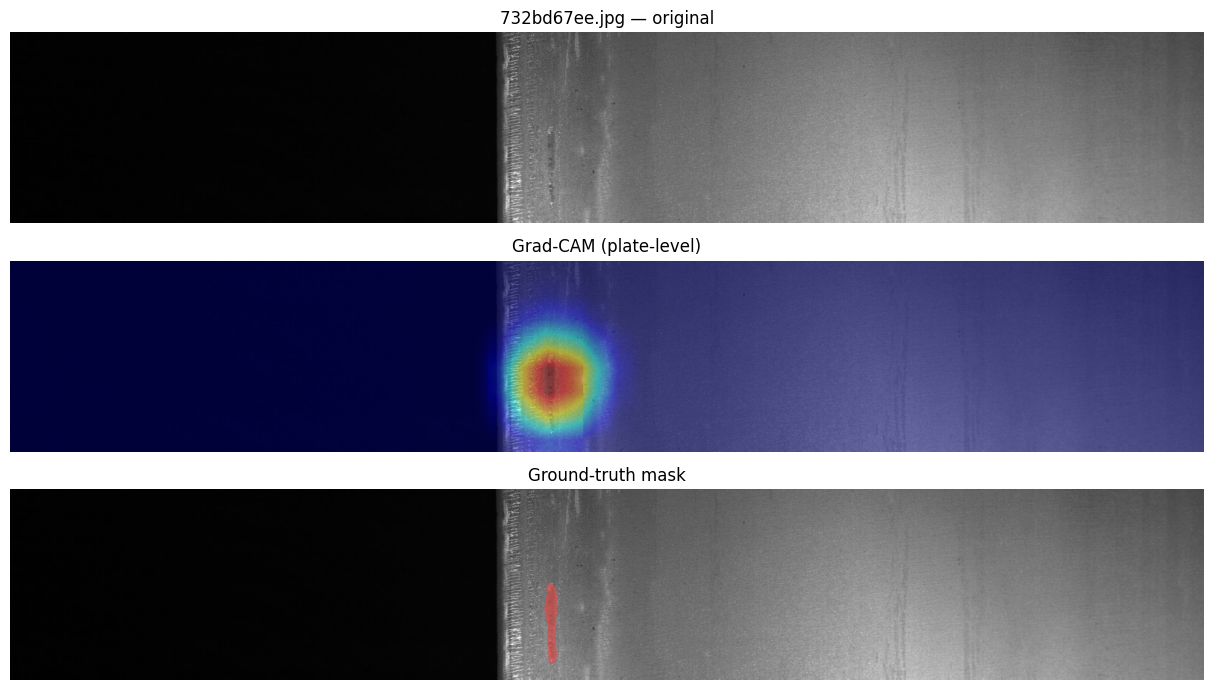

saved outputs/heatmaps/gradcam_732bd67ee.png


In [3]:
# ── Cell 18: Plate-level Grad-CAM heatmap ─────────────────────────────────────
os.makedirs("outputs/heatmaps", exist_ok=True)

def plate_gradcam(image_id, cfg, cam_obj, device, prob_gate=0.5):
    ps, st = cfg["patch_size"], cfg["patch_stride"]
    H, W   = cfg["img_h"], cfg["img_w"]
    img    = cv2.cvtColor(cv2.imread(f"{cfg['image_dir']}/{image_id}"), cv2.COLOR_BGR2RGB)
    accum  = np.zeros((H, W), dtype=np.float32)
    count  = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H-ps+1, st):
        for x in range(0, W-ps+1, st):
            patch = img[y:y+ps, x:x+ps]
            t = norm(image=patch)["image"].unsqueeze(0).to(device)
            cam, p = cam_obj(t, class_idx=1)
            if p >= prob_gate:
                accum[y:y+ps, x:x+ps] += cam * p
                count[y:y+ps, x:x+ps] += 1
    heat = accum / np.maximum(count, 1)
    return img, heat

for img_id in list(has_crack)[:3]:
    img, heat = plate_gradcam(img_id, cfg, cam_obj, device)
    row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    gt   = decode_rle(row.iloc[0]["EncodedPixels"]) if not row.empty else np.zeros((cfg["img_h"], cfg["img_w"]))
    cam_overlay  = overlay_cam(img, heat)
    mask_overlay = img.copy()
    mask_overlay[gt==1] = mask_overlay[gt==1]*0.35 + np.array([226,75,74])*0.65

    fig, ax = plt.subplots(3,1, figsize=(14,7))
    ax[0].imshow(img);                           ax[0].set_title(f"{img_id} — original")
    ax[1].imshow(cam_overlay);                   ax[1].set_title("Grad-CAM (plate-level)")
    ax[2].imshow(mask_overlay.astype(np.uint8)); ax[2].set_title("Ground-truth mask")
    for a in ax: a.axis("off")
    plt.tight_layout()
    out = f"outputs/heatmaps/gradcam_{img_id.replace('.jpg','')}.png"
    plt.savefig(out, dpi=140); plt.show()
    print("saved", out)

In [5]:
# ── Cell 19: Error analysis gallery (fixed — Grad-CAM needs grad) ─────────────
import os, cv2, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
import json

for sub in ("tp","fp","fn"):
    os.makedirs(f"outputs/errors/{sub}", exist_ok=True)

# --- Make sure params can backprop (hooks need a live graph) -----------------
for p in model.parameters():
    p.requires_grad_(True)
model.eval()

# --- Dataset (mirrors Cell 3) ------------------------------------------------
with open(SPLIT_JSON) as f:
    split = json.load(f)
test_ids = split["test"]

class SteelPatchDataset(Dataset):
    def __init__(self, image_ids, df, cfg):
        self.items = []
        ps, st = cfg["patch_size"], cfg["patch_stride"]
        H, W   = cfg["img_h"], cfg["img_w"]
        for img_id in image_ids:
            row  = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
            rle  = row.iloc[0]["EncodedPixels"] if not row.empty else np.nan
            mask = decode_rle(rle, H, W)
            for y in range(0, H-ps+1, st):
                for x in range(0, W-ps+1, st):
                    label = int(mask[y:y+ps, x:x+ps].sum() > 50)
                    self.items.append((img_id, y, x, label))
        self.cfg = cfg
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        img_id, y, x, label = self.items[i]
        ps = self.cfg["patch_size"]
        img = cv2.cvtColor(cv2.imread(f"{self.cfg['image_dir']}/{img_id}"), cv2.COLOR_BGR2RGB)
        patch = img[y:y+ps, x:x+ps]
        t = norm(image=patch)["image"]
        return t, label

test_loader = DataLoader(SteelPatchDataset(test_ids, df, cfg),
                         batch_size=64, shuffle=False, num_workers=0)

# ── Pass 1: score every patch (fast, no grad) ────────────────────────────────
all_labels, all_probs = [], []
examples = {"tp": [], "fp": [], "fn": []}     # store tensors we want to CAM later
K = 12

with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.softmax(model(imgs.to(device)), 1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        labels_np = labels.numpy()
        all_labels.extend(labels_np.tolist())
        all_probs.extend(probs.tolist())

        for img, y, p, pr in zip(imgs, labels_np, preds, probs):
            bucket = {(1,1):"tp", (0,1):"fp", (1,0):"fn"}.get((int(y), int(p)))
            if bucket is None or len(examples[bucket]) >= K:
                continue
            # clone to CPU so we keep it around after the loader moves on
            examples[bucket].append((img.clone(), float(pr)))

print("Pass 1 done. patches scored:", len(all_labels),
      "| examples gathered:", {k: len(v) for k, v in examples.items()})

# ── Pass 2: Grad-CAM ONLY on the chosen examples (grad enabled) ──────────────
for bucket, items in examples.items():
    for i, (img_tensor, pr) in enumerate(items):
        # de-normalise for display
        arr = img_tensor.permute(1, 2, 0).cpu().numpy()
        arr = arr * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        arr = np.clip(arr * 255, 0, 255).astype(np.uint8)

        # Grad-CAM — OUTSIDE no_grad, fresh forward pass per image
        x = img_tensor.unsqueeze(0).to(device)
        cam, _ = cam_obj(x, class_idx=1)

        side = np.concatenate([arr, overlay_cam(arr, cam)], axis=1)
        out  = f"outputs/errors/{bucket}/{bucket}_{i:02d}_p{pr:.2f}.png"
        cv2.imwrite(out, cv2.cvtColor(side, cv2.COLOR_RGB2BGR))

print("Saved:", {k: len(v) for k, v in examples.items()}, "→ outputs/errors/")

Pass 1 done. patches scored: 13827 | examples gathered: {'tp': 12, 'fp': 12, 'fn': 12}
Saved: {'tp': 12, 'fp': 12, 'fn': 12} → outputs/errors/


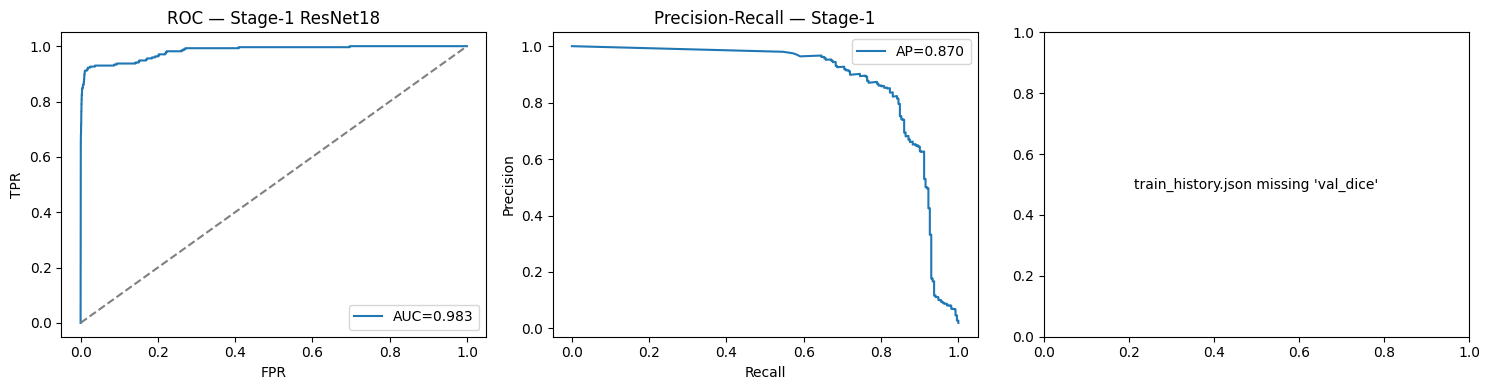

saved outputs/plots/evaluation_plots.png


In [6]:
# ── Cell 20: Evaluation plots (ROC + PR + training curves from disk) ──────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
os.makedirs("outputs/plots", exist_ok=True)

fpr, tpr, _  = roc_curve(all_labels, all_probs); roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

# Load Stage-2 training history if it was saved to disk
if os.path.exists(HIST_JSON):
    with open(HIST_JSON) as f: hist = json.load(f)
else:
    hist = {}

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}"); ax[0].plot([0,1],[0,1],"--",c="grey")
ax[0].set(title="ROC — Stage-1 ResNet18", xlabel="FPR", ylabel="TPR"); ax[0].legend()

ax[1].plot(rec, prec, label=f"AP={ap:.3f}")
ax[1].set(title="Precision-Recall — Stage-1", xlabel="Recall", ylabel="Precision"); ax[1].legend()

if "val_dice" in hist:
    ax[2].plot(hist["val_dice"], label="U-Net pretrained Dice")
    if "val_dice_random" in hist:
        ax[2].plot(hist["val_dice_random"], label="U-Net random Dice")
    ax[2].set(title="Stage-2 training", xlabel="epoch", ylabel="Dice"); ax[2].legend(); ax[2].grid()
else:
    ax[2].text(0.5,0.5,"train_history.json missing 'val_dice'", ha="center", va="center")

plt.tight_layout()
plt.savefig("outputs/plots/evaluation_plots.png", dpi=140); plt.show()
print("saved outputs/plots/evaluation_plots.png")

In [7]:
import json
with open("train_history.json") as f: hist = json.load(f)
print("keys:", list(hist.keys()))
print({k: (len(v) if isinstance(v, list) else v) for k, v in hist.items()})

keys: ['train_loss', 'val_loss', 'val_f1']
{'train_loss': 20, 'val_loss': 20, 'val_f1': 20}


In [33]:
import json, os
os.makedirs("outputs/logs", exist_ok=True)
json.dump({
    "val_dice":        hist_pre["val_dice"],
    "val_iou":         hist_pre["val_iou"],
    "val_loss":        hist_pre["val_loss"],
    "val_dice_random": hist_rand["val_dice"],
}, open("train_history_unet.json","w"))
print("saved train_history_unet.json")

saved train_history_unet.json


loaded train_history.json → keys: ['train_loss', 'val_loss', 'val_f1']
loaded train_history_unet.json → keys: ['val_dice', 'val_iou', 'val_loss', 'val_dice_random']


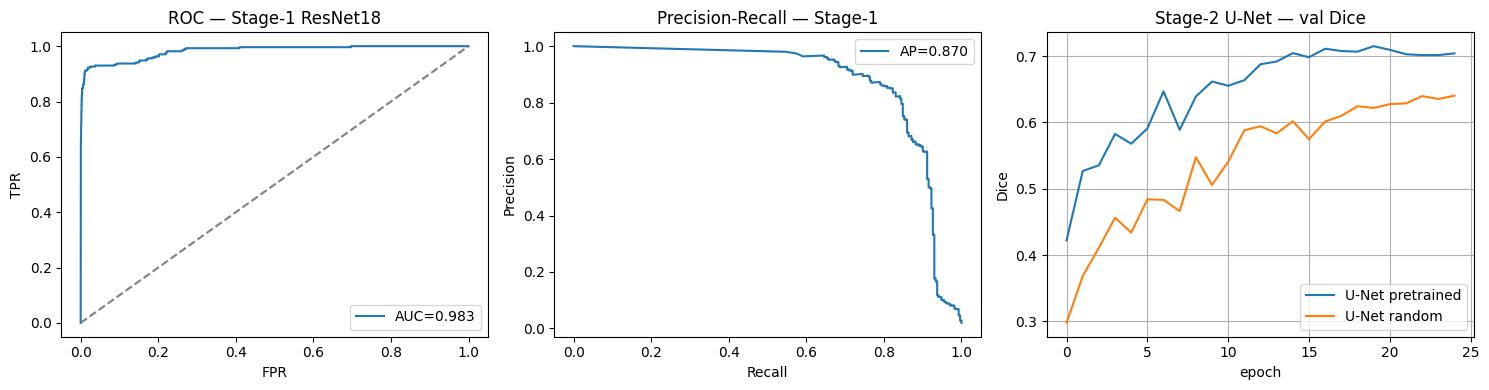

saved outputs/plots/evaluation_plots.png


In [34]:
# ── Cell 20: Evaluation plots (ROC + PR + whatever training history exists) ──
import os, json
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

os.makedirs("outputs/plots", exist_ok=True)

# --- ROC + PR from Cell 19's all_labels / all_probs --------------------------
fpr, tpr, _  = roc_curve(all_labels, all_probs); roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

# --- Load any training history available -------------------------------------
hist = {}
for candidate in ["train_history.json", "train_history_unet.json",
                  "outputs/logs/train_history.json"]:
    if os.path.exists(candidate):
        with open(candidate) as f: hist.update(json.load(f))
        print("loaded", candidate, "→ keys:", list(json.load(open(candidate)).keys()))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}"); ax[0].plot([0,1],[0,1],"--",c="grey")
ax[0].set(title="ROC — Stage-1 ResNet18", xlabel="FPR", ylabel="TPR"); ax[0].legend()

ax[1].plot(rec, prec, label=f"AP={ap:.3f}")
ax[1].set(title="Precision-Recall — Stage-1", xlabel="Recall", ylabel="Precision"); ax[1].legend()

# --- Third panel: detect and plot whatever is available ----------------------
plotted = False

# Case A: Stage-2 U-Net Dice history (TL vs random)
if "val_dice" in hist:
    ax[2].plot(hist["val_dice"], label="U-Net pretrained")
    if "val_dice_random" in hist:
        ax[2].plot(hist["val_dice_random"], label="U-Net random")
    ax[2].set(title="Stage-2 U-Net — val Dice", xlabel="epoch", ylabel="Dice")
    ax[2].legend(); ax[2].grid(); plotted = True

# Case B: Stage-1 classifier curves
elif any(k in hist for k in ("train_loss","val_loss","val_f1","val_auc")):
    twin = ax[2].twinx()
    any_loss = False
    if "train_loss" in hist:
        ax[2].plot(hist["train_loss"], label="train loss", color="tab:blue"); any_loss=True
    if "val_loss" in hist:
        ax[2].plot(hist["val_loss"],   label="val loss",   color="tab:orange"); any_loss=True
    if "val_f1" in hist:
        twin.plot(hist["val_f1"],   "--", label="val F1",  color="tab:green")
    if "val_auc" in hist:
        twin.plot(hist["val_auc"],  "--", label="val AUC", color="tab:red")
    ax[2].set(title="Stage-1 training", xlabel="epoch", ylabel="loss")
    twin.set_ylabel("F1 / AUC")
    lines_l, labels_l = ax[2].get_legend_handles_labels()
    lines_r, labels_r = twin.get_legend_handles_labels()
    ax[2].legend(lines_l + lines_r, labels_l + labels_r, loc="lower left")
    ax[2].grid(); plotted = True

if not plotted:
    ax[2].text(0.5, 0.5, "no training history found\n(train_history.json empty or missing)",
               ha="center", va="center"); ax[2].set(xticks=[], yticks=[])

plt.tight_layout()
plt.savefig("outputs/plots/evaluation_plots.png", dpi=140); plt.show()
print("saved outputs/plots/evaluation_plots.png")

In [35]:
# ── Cell 20b: CAM-faithfulness metric ─────────────────────────────────────────
os.makedirs("outputs/logs", exist_ok=True)

ious = []
for img_id in list(has_crack)[:30]:
    _, heat = plate_gradcam(img_id, cfg, cam_obj, device, prob_gate=0.5)
    row = df[(df["ImageId"]==img_id) & (df["ClassId"]==1)]
    if row.empty: continue
    gt    = decode_rle(row.iloc[0]["EncodedPixels"])
    pred  = (heat > 0.5).astype(np.uint8)
    union = (pred | gt).sum()
    if union: ious.append(((pred & gt).sum()) / union)

mean_iou = float(np.mean(ious)) if ious else 0.0
print(f"Mean Grad-CAM ↔ ground-truth IoU over {len(ious)} plates: {mean_iou:.3f}")

with open("outputs/logs/xai_faithfulness.txt","w") as f:
    f.write(f"mean_iou,{mean_iou:.4f}\nn_plates,{len(ious)}\n")

Mean Grad-CAM ↔ ground-truth IoU over 30 plates: 0.147


In [37]:
# ── Cell 21: Export Stage-1 for deployment (clean copy, no hooks) ─────────────
import time, copy
from torchvision import models
import torch, torch.nn as nn

# --- Build a fresh, hook-free copy of the classifier ------------------------
def build_resnet_clean(backbone="resnet18"):
    m = getattr(models, backbone)(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, 2))
    return m

ckpt = torch.load("checkpoints/resnet18_best.pth",
                  map_location=device, weights_only=False)

export_model = build_resnet_clean("resnet18").to(device)
export_model.load_state_dict(ckpt["model_state"])
export_model.eval()
for p in export_model.parameters():
    p.requires_grad_(False)            # ← critical: trace hates grad-tracking params

example = torch.randn(1, 3, 256, 256).to(device)

# --- TorchScript trace -------------------------------------------------------
with torch.no_grad():
    traced_clf = torch.jit.trace(export_model, example, strict=False)
traced_clf.save("checkpoints/resnet18_traced.pt")
print("saved checkpoints/resnet18_traced.pt")

# --- Sanity check: loaded TorchScript gives same logits ----------------------
loaded = torch.jit.load("checkpoints/resnet18_traced.pt", map_location=device).eval()
with torch.no_grad():
    a = export_model(example)
    b = loaded(example)
print(f"traced vs eager max abs diff: {(a-b).abs().max().item():.2e}")

# --- ONNX export -------------------------------------------------------------
torch.onnx.export(
    export_model, example, "checkpoints/resnet18.onnx",
    opset_version=17,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "N"}, "logits": {0: "N"}},
)
print("saved checkpoints/resnet18.onnx")

# --- Latency benchmark on the clean export model -----------------------------
with torch.no_grad():
    for _ in range(5): _ = export_model(example)            # warmup
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): _ = export_model(example)
    if device.type == "cuda": torch.cuda.synchronize()
print(f"Stage-1 avg latency @ batch=1: {(time.time()-t0)/50*1000:.2f} ms")

saved checkpoints/resnet18_traced.pt
traced vs eager max abs diff: 0.00e+00


OnnxExporterError: Module onnx is not installed!

In [38]:
!pip install -q onnx


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
torch.onnx.export(
    export_model, example, "checkpoints/resnet18.onnx",
    opset_version=17,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "N"}, "logits": {0: "N"}},
)
print("saved checkpoints/resnet18.onnx")

saved checkpoints/resnet18.onnx


In [40]:
# ── Cell 22: Deployment benchmarks — fills numbers for deployment.md ──────────
import os, time, json, numpy as np, torch

os.makedirs("outputs/logs", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load fresh clean export models (no CAM hooks)
clf_ts  = torch.jit.load("checkpoints/resnet18_traced.pt", map_location=device).eval()
unet_ts = torch.jit.load("unet_traced.pt",                 map_location=device).eval()

def bench(model, x, n=50, warmup=5):
    with torch.no_grad():
        for _ in range(warmup): _ = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n): _ = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / n * 1000   # ms

results = {}

# --- Stage-1 single patch (batch=1) and batch=8 ------------------------------
results["stage1_b1_ms"] = bench(clf_ts,  torch.randn(1, 3, 256, 256).to(device))
results["stage1_b8_ms"] = bench(clf_ts,  torch.randn(8, 3, 256, 256).to(device))

# --- Stage-2 single patch (batch=1) and batch=8 ------------------------------
results["stage2_b1_ms"] = bench(unet_ts, torch.randn(1, 3, 256, 256).to(device))
results["stage2_b8_ms"] = bench(unet_ts, torch.randn(8, 3, 256, 256).to(device))

# --- End-to-end plate: 11 patches of 256×256 at stride 128 across 256×1600 ---
PS, ST, H, W = cfg["patch_size"], cfg["patch_stride"], cfg["img_h"], cfg["img_w"]
n_patches = ((W - PS) // ST + 1) * ((H - PS) // ST + 1)
print(f"patches per plate: {n_patches}")

# Measure: per-patch Stage-1 cost × n_patches + Stage-2 only on flagged patches
stage1_per_plate = results["stage1_b1_ms"] * n_patches
# How many plates actually trigger Stage-2? Use all_probs from Cell 19
flag_rate = float(np.mean(np.array(all_probs) >= 0.5)) if len(all_probs) else 0.3
results["flag_rate"] = flag_rate
stage2_per_plate = results["stage2_b1_ms"] * n_patches * flag_rate
results["plate_cascade_ms"] = stage1_per_plate + stage2_per_plate
results["plate_naive_ms"]   = (results["stage1_b1_ms"] + results["stage2_b1_ms"]) * n_patches
results["cascade_speedup"]  = results["plate_naive_ms"] / results["plate_cascade_ms"]

# --- Print a ready-to-paste markdown table -----------------------------------
print("\n### Latency table\n")
print("| Component                        | Latency (ms) |")
print("|----------------------------------|--------------|")
print(f"| Stage-1 ResNet18 (batch=1)       | {results['stage1_b1_ms']:.2f} |")
print(f"| Stage-1 ResNet18 (batch=8)       | {results['stage1_b8_ms']:.2f} |")
print(f"| Stage-2 U-Net (batch=1)          | {results['stage2_b1_ms']:.2f} |")
print(f"| Stage-2 U-Net (batch=8)          | {results['stage2_b8_ms']:.2f} |")
print(f"| End-to-end plate, naive          | {results['plate_naive_ms']:.2f} |")
print(f"| End-to-end plate, cascade        | {results['plate_cascade_ms']:.2f} |")
print(f"\nCascade speedup: **{results['cascade_speedup']:.2f}×**   "
      f"(flag-rate on test set: {flag_rate*100:.1f}%)")
print(f"Sustained throughput (cascade): **{1000/results['plate_cascade_ms']:.1f} plates/sec**")

with open("outputs/logs/deployment_bench.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved outputs/logs/deployment_bench.json")

patches per plate: 11

### Latency table

| Component                        | Latency (ms) |
|----------------------------------|--------------|
| Stage-1 ResNet18 (batch=1)       | 4.93 |
| Stage-1 ResNet18 (batch=8)       | 1.88 |
| Stage-2 U-Net (batch=1)          | 5.10 |
| Stage-2 U-Net (batch=8)          | 6.03 |
| End-to-end plate, naive          | 110.41 |
| End-to-end plate, cascade        | 55.21 |

Cascade speedup: **2.00×**   (flag-rate on test set: 1.7%)
Sustained throughput (cascade): **18.1 plates/sec**

Saved outputs/logs/deployment_bench.json
